In [ ]:
!pip install -q gymnasium[classic-control]==1.2.2 torch numpy

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random

# Set the random seed for reproducibility
seed = 123
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

/home/riccardo_monte/anaconda3/envs/cleanrl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Print state and action

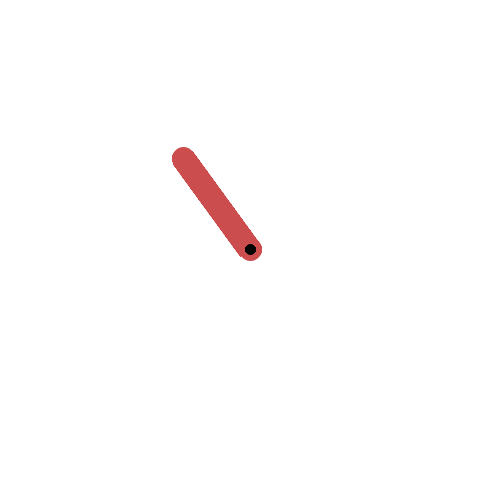

In [3]:
env = gym.make("Pendulum-v1")
state, _ = env.reset(seed=seed)

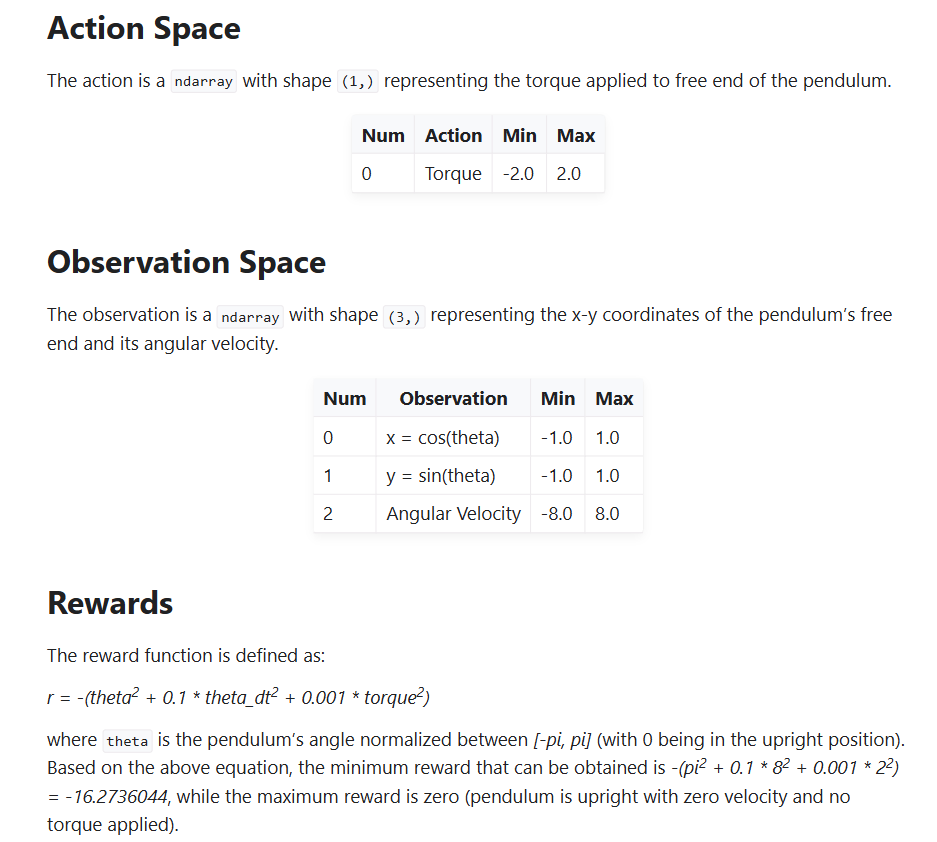

In [4]:
print(state)

[ 0.4123625   0.91101986 -0.89235795]


In [5]:
random_action = env.action_space.sample()

In [6]:
print(random_action)

[-1.4034027]


# State and action bounds

In [7]:
print(env.observation_space)

Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)


In [8]:
print(env.action_space)

Box(-2.0, 2.0, (1,), float32)


# Actor Network for DDPG

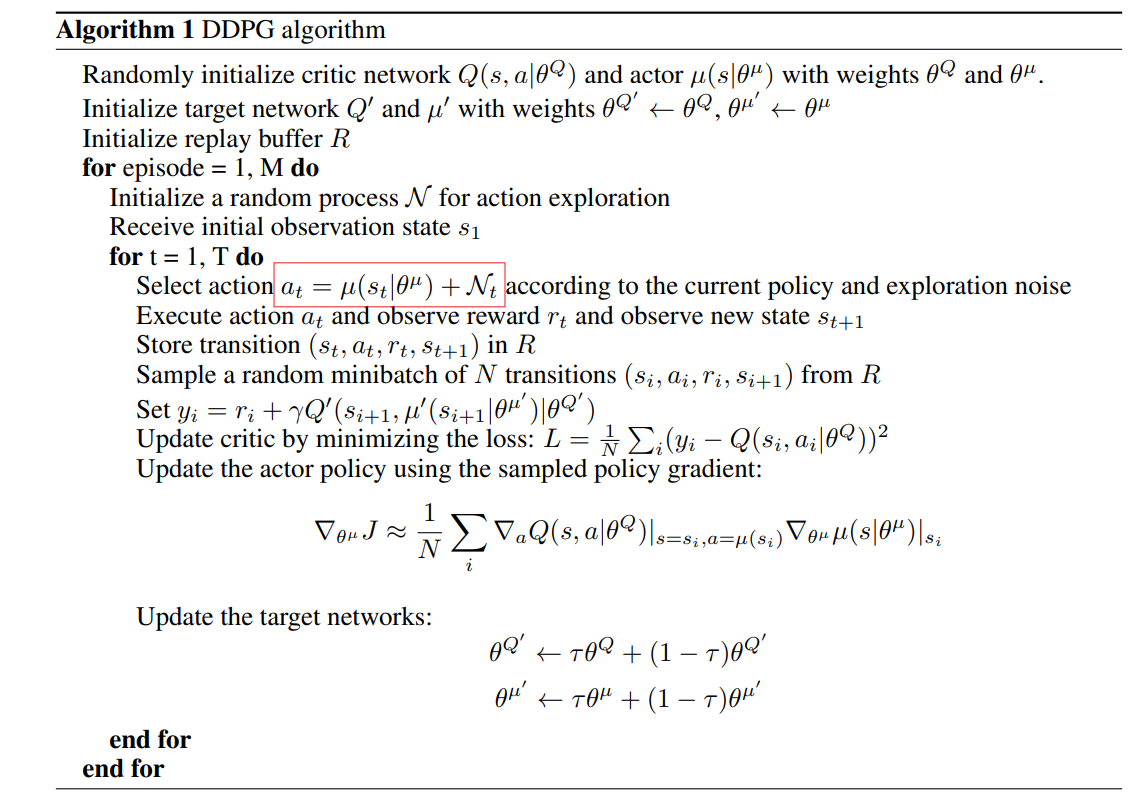

DDPG policy:



1.   The actual policy (target polict $\mu$) is deterministic -> output of the actor NN = actual action
2.   For exploration, DDPG is off-policy and adds noise ($\mathcal{N}_t$) to the actual output of the actor network



In [9]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.layer_1 = nn.Linear(state_dim, 128)
        self.layer_2 = nn.Linear(128, 128)
        self.layer_3 = nn.Linear(128, action_dim)
        self.max_action = max_action

    def forward(self, x):
        x = F.silu(self.layer_1(x))
        x = F.silu(self.layer_2(x))
        x = torch.tanh(self.layer_3(x)) * self.max_action
        return x

    def save(self, filename):
        torch.save(self.state_dict(), filename)

    def load(self, filename, device='cpu'):
        self.load_state_dict(torch.load(filename, map_location=device))

# Critic net

DDPG uses a critic network to estimate $Q(s,a)$. We need to provide both the state and the action as input to the critic network:

In [10]:
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.layer_1 = nn.Linear(state_dim + action_dim, 128) # concat state with action
        self.layer_2 = nn.Linear(128, 128)
        self.layer_3 = nn.Linear(128, 1)

    def forward(self, s, a):
        x = torch.cat([s, a], 1)
        x = F.silu(self.layer_1(x))
        x = F.silu(self.layer_2(x))
        x = self.layer_3(x)
        return x

    def save(self, filename):
        torch.save(self.state_dict(), filename)

    def load(self, filename, device='cpu'):
        self.load_state_dict(torch.load(filename, map_location=device))

# Get the first state: reset function

The .reset() function (any environment has this function) returns the initial state and resets the environment to the initial conditions.

In [11]:
state, _ = env.reset()

In [12]:
print(state.shape)

(3,)


# Environment step function

In [13]:
random_action = env.action_space.sample()

In [14]:
next_state, reward, terminated, truncated, info = env.step(random_action)

In [15]:
reward

-3.1270721786225266

In [16]:
next_state

array([-0.25003055, -0.96823794, -1.3295481 ], dtype=float32)

In [17]:
terminated

False

In [18]:
truncated

False

When either *truncated* or *terminated* is True, we **have to reset**.

In [19]:
done = terminated or truncated

# A transition to save into the buffer

Once we do

```
next_state, reward, terminated, truncated, info = env.step(action)
```

We have a transition $(s_t,a_t,r_{t+1},s_{t+1})$ where $s_t$=state, $a_t$=action, $s_{t+1}$=next_state and $r_{t+1}$=reward.




# Buffer

In [20]:
# Replay Buffer to store old transtions
class ReplayBuffer:
    def __init__(self, max_size=1e6):
        self.buffer = deque(maxlen=int(max_size))

    def add(self, state, action, next_state, reward, terminated):
        self.buffer.append((state, action, next_state, reward, terminated))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, next_state, reward, terminated = zip(*batch)
        return (np.array(state), np.array(action), np.array(next_state),
                np.array(reward), np.array(terminated))

# DDPG agent

Here we define the training logic based on the DPG theory:



1.   In the ```__init__```, we create an instance for the actor, critic and the corresponding target nets
2.   Still in the ```__init__```, we create an empty buffer
3.  ```select_best_action()```: given the state (numpy array), returns the determinstic action $\mu(s)$
4. ```select_action()```: returns a noisy action for exploration
5. ```train()```: update function. Samples a batch of transitions and updates actor/critic with DDPG losses



In [21]:
# DDPG Agent
class DDPG(object):
    def __init__(self, state_dim, action_dim, max_action, device):

        # define networks, their respective optimizers, and target networks
        self.actor = Actor(state_dim, action_dim, max_action).float().to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).float().to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=3e-4)

        self.critic = Critic(state_dim, action_dim).float().to(device)
        self.critic_target = Critic(state_dim, action_dim).float().to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.replay_buffer = ReplayBuffer()
        self.max_action = max_action
        self.device = device

    def select_best_action(self, state):
        # best action for the agent
        state = torch.FloatTensor(state.reshape(1, -1)).float().to(device)
        return self.actor(state).cpu().data.numpy().flatten()

    def select_action(self, state):
        # action with some exploration noise
        action = self.select_best_action(state)
        return action + np.random.randn(*action.shape) * 0.01

    def train(self, batch_size=256, gamma=0.99, tau=0.005):
        # 1. Sample a batch from the replay buffer
        # 2. Compute the target Q value
        # 3. Update critic by minimizing the loss
        # 4. Update actor proportional to the gradients
        # 5. Update the target networks

        state, action, next_state, reward, terminated = self.replay_buffer.sample(batch_size)

        state = torch.FloatTensor(state).float().to(self.device)
        action = torch.FloatTensor(action).float().to(self.device)
        next_state = torch.FloatTensor(next_state).float().to(self.device)
        # pay attention to the shape of your tensors (*)
        reward = torch.FloatTensor(reward).float().unsqueeze(-1).to(self.device) / 10
        terminated = torch.FloatTensor(terminated).float().unsqueeze(-1).to(self.device)

        target_Q = self.critic_target(next_state, self.actor_target(next_state))
        # (*) otherwise here target_Q will have a very weird shape, and torch will not complain... (and you won't learn anything)
        target_Q = reward + ((1 - terminated) * gamma * target_Q).detach()
        current_Q = self.critic(state, action)
        critic_loss = F.mse_loss(current_Q, target_Q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss = -self.critic(state, self.actor(state)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        # this is slightly different from the original DDPG, instead
        # of doing a drastic reset to the target networks,
        # you slowly update the targets using an Exponential Moving Average (EMA)
        # (consider that this has like a billion names, so you might find it as Polyak averaging or something like that)
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

# Evaluation

10 episodes evaluation

In [22]:
def evaluate(agent, env, seed, episodes=10):
    """
    Evaluates the agent on the environment for a given number of episodes.
    """
    total_reward = 0
    for e in range(episodes):
        state, _ = env.reset() if e > 0 else env.reset(seed=seed+100)
        episode_reward = 0
        while True:
            action = agent.select_best_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            if done:
                break
        total_reward += episode_reward
    average_reward = total_reward / episodes
    print(f"Average Cumulative Reward during Evaluation: {average_reward}")
    return average_reward

# Main

In [23]:
# define the envs and the envs for evaluation
env = gym.make("Pendulum-v1")
eval_env = gym.make("Pendulum-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

device = torch.device("cuda")

# define your agent
agent = DDPG(state_dim, action_dim, max_action, device)

In [24]:
def main():
    evals = []
    # it will take 8 minutes on the server, probably 2x/3x more on your pc
    episodes = 100
    evaluation_interval = 5

    for episode in range(episodes):
        state, _ = env.reset() if episode > 0 else env.reset(seed=seed)
        episode_reward = 0
        while True:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.replay_buffer.add(state, action, next_state, reward, terminated)
            state = next_state
            episode_reward += reward

            #print(f"Episode {episode + 1} Reward: {episode_reward}")
            if len(agent.replay_buffer.buffer) > 2000:
                agent.train()
            if done:
              if (episode + 1) % evaluation_interval == 0:
                  print(f"Episode {episode+1} / {episodes} - ", end="")
                  evals.append(evaluate(agent, eval_env, seed))

              break

    return evals

In [25]:
eval_returns = main()

Episode 5 / 100 - Average Cumulative Reward during Evaluation: -1359.5368729453971
Episode 10 / 100 - Average Cumulative Reward during Evaluation: -1359.5368729453971
Episode 15 / 100 - Average Cumulative Reward during Evaluation: -1401.1568876215156
Episode 20 / 100 - Average Cumulative Reward during Evaluation: -596.1930140873953
Episode 25 / 100 - Average Cumulative Reward during Evaluation: -654.4830323902936
Episode 30 / 100 - Average Cumulative Reward during Evaluation: -170.02828709920672
Episode 35 / 100 - Average Cumulative Reward during Evaluation: -171.23101666252907
Episode 40 / 100 - Average Cumulative Reward during Evaluation: -178.53524501742282
Episode 45 / 100 - Average Cumulative Reward during Evaluation: -361.16540959875545
Episode 50 / 100 - Average Cumulative Reward during Evaluation: -164.81419529586802
Episode 55 / 100 - Average Cumulative Reward during Evaluation: -196.54705210406274
Episode 60 / 100 - Average Cumulative Reward during Evaluation: -196.8064844946

# Plot

Text(0.5, 1.0, 'DDPG on Pendulum-v1')

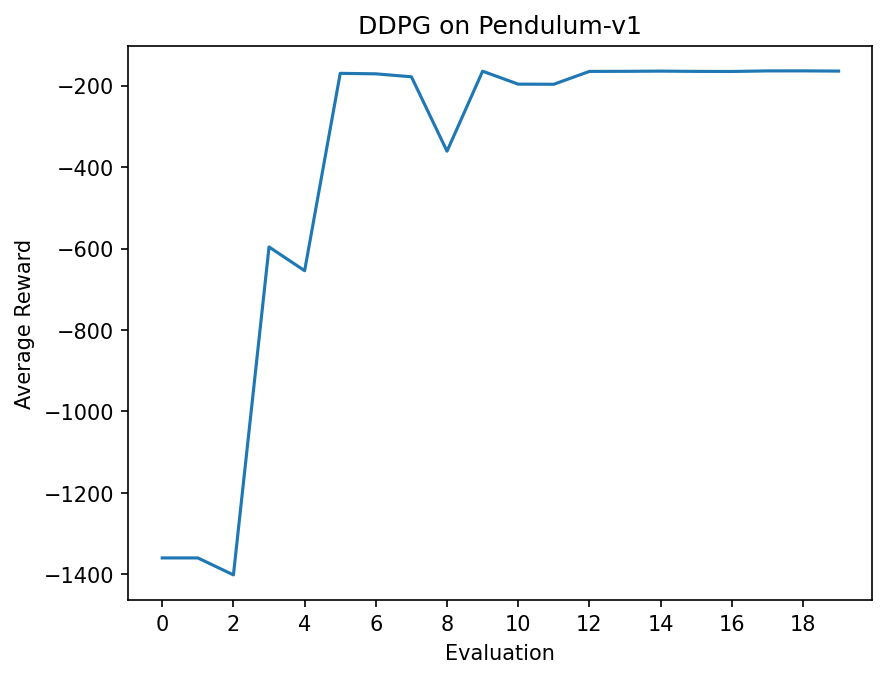

In [30]:
import matplotlib.pyplot as plt
plt.figure(dpi=150)
x = np.arange(0, len(eval_returns), 2)
plt.plot(eval_returns)
plt.xticks(x)
plt.xlabel("Evaluation")
plt.ylabel("Average Reward")
plt.title("DDPG on Pendulum-v1")

# Create gif

In [39]:
import gymnasium as gym
import imageio.v2 as imageio

def record_episode_gif_direct(
    agent,
    env_id,
    seed,
    gif_path="evaluation.gif",
    fps=30
):
    """
    Runs one evaluation episode using the agent and saves it directly as a GIF.
    Uses per-frame duration instead of deprecated fps.
    """

    env = gym.make(env_id, render_mode="rgb_array")

    frames = []

    state, _ = env.reset(seed=seed)
    done = False

    while not done:
        frames.append(env.render())

        action = agent.select_best_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    frames.append(env.render())
    env.close()

    # Convert FPS to duration in milliseconds per frame
    duration_ms = int(1000 / fps)

    imageio.mimsave(
        gif_path,
        frames,
        duration=duration_ms
    )

    print(f"GIF saved to: {gif_path}")


In [40]:
record_episode_gif_direct(
    agent=agent,
    env_id="Pendulum-v1",
    seed=123,
    gif_path="pendulum_eval.gif",
    fps=30
)

GIF saved to: pendulum_eval.gif
